In [1]:
import os
import sys
sys.path.append("../../src")
import kibble_zurek as kz
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt 
from numpy import sin, cos, sqrt, exp, log
from matplotlib.pyplot import plot, scatter, loglog, yscale, xscale, xlim, ylim, title,xlabel,ylabel,title

In [2]:
taus = np.logspace(-4,2.5,75)
Ls = np.array([2,4,8,16,32,64,128,256,512,1024])

states_L = []
for L in tqdm(Ls):
    taus_L = []
    for tau in taus:
        state = kz.state(L,tau,tau)
        taus_L.append(state)
    states_L.append(taus_L)

100%|██████████| 10/10 [01:41<00:00, 10.14s/it]


In [7]:
test_state = kz.state(100,500,0)

print(f"\n my original: {kz.G(1,test_state)}")


 my original: (0.632344117383485-0j)


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_11459/2598495296.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


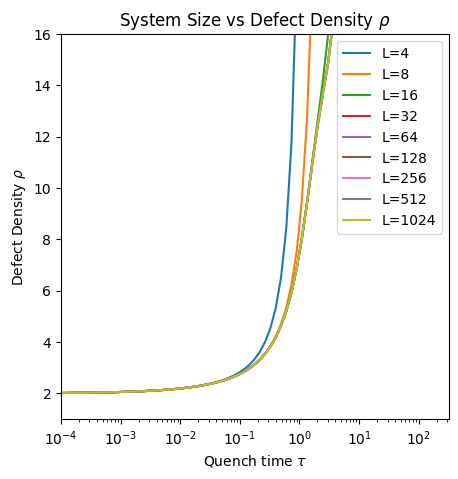

<Figure size 640x480 with 0 Axes>

In [79]:
##Plot:
fig, ax = plt.subplots(figsize=(5,5))
a=0 #y axis
b=0 #x axis
plt.figure()
for i,states in enumerate(states_L[:]):
    if i ==0:
        continue
    data = []
    for s in states:
        data.append((1-kz.G(1,s))/2)
    data=np.array(data)
    ax.plot(taus,1/data,label=f"L={Ls[i]}")
   # ax.plot(taus,1/data,label="1/DATA")
#ax.plot(taus,(taus**(-1/2)/taus[31]**(-1/2))/2,ls="--",color="black",lw=1,label=r"$\tau^{-1/2}$")
# plot(taus,taus**(-4/2),ls="--",color="black")

ax.legend()

ax.set_xscale("log")
ax.set_xlim(.0001,taus[-1])
#ax.set_yscale("log")

ax.set_ylim(1,16)
#ax.set_xlim(1,50)
ax.set_ylabel(r"Defect Density $\rho$")
ax.set_xlabel(r"Quench time $\tau$")
ax.set_title(r"System Size vs Defect Density $\rho$")
fig.show()
#fig.savefig("Defect_density_finite_size.png")

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_11459/1225800051.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


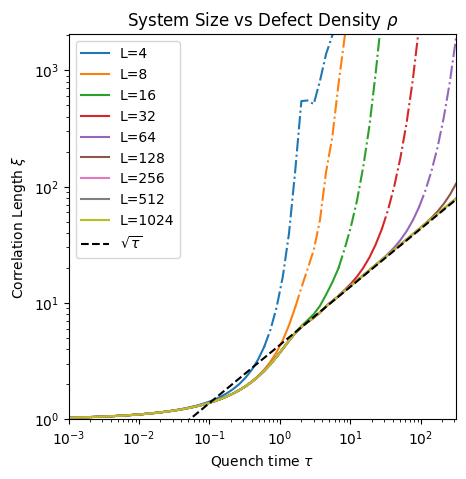

In [77]:
fig, ax = plt.subplots(figsize=(5,5))

for i, states in enumerate(states_L):
    if i == 0:
        continue
    data = np.array([(1 - kz.G(1, s)) / 2 for s in states])
    y = 1/(2*data)
    threshold = Ls[i]
    mask = y > threshold

    # get one color for this curve
    color = ax._get_lines.get_next_color()

    # segment by contiguous mask runs to avoid a gap
    switch = np.flatnonzero(mask[1:] ^ mask[:-1]) + 1
    cuts = np.r_[0, switch, len(taus)]
    first = True
    for a, b in zip(cuts[:-1], cuts[1:]):
        seg_ls = "-." if np.all(mask[a:b]) else "-"
        ax.plot(taus[a:b+1], y[a:b+1], ls=seg_ls,
                color=color,
                label=f"L={Ls[i]}" if first else None)
        first = False

ax.plot(taus,2*taus**(1/2)/(2*taus[31]**(1/2)),color="Black",ls="--",label=r"$\sqrt{\tau}$")
ax.legend()
ax.set_xscale("log")
ax.set_xlim(.001, taus[-1])    # keep your bounds
ax.set_ylim(1, 2048)          # keep your bounds
ax.set_yscale("log")
ax.set_ylabel(r"Correlation Length $\xi$")
ax.set_xlabel(r"Quench time $\tau$")
ax.set_title(r"System Size vs Defect Density $\rho$")
fig.show()


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_11459/3979264515.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  Corrs[tau,k]=(kz.G(r[k],s))


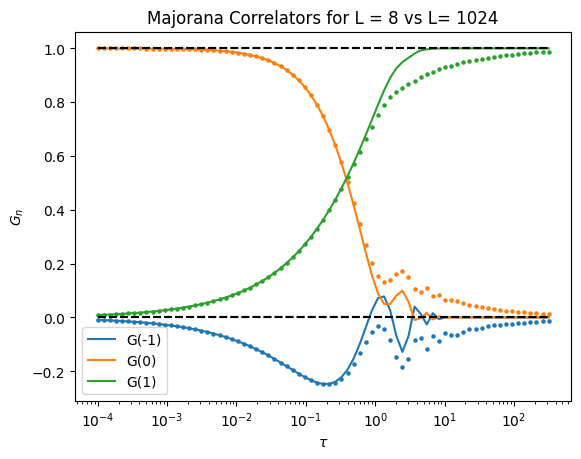

In [78]:
##Plot:

for i,states in enumerate([states_L[2],states_L[-1]]):

    r = np.arange(-1,2)
    Corrs = np.zeros([len(taus),len(r)])
    labels = [f"G({ri})" for ri in r]
    for tau,s in enumerate(states):
        for k in range(len(r)):
            Corrs[tau,k]=(kz.G(r[k],s))
        
    titles=[Ls[1],Ls[-1]]
    if i ==0:
        plot(taus,Corrs,label= labels)
    if i ==1:
        for j in range(3):
            scatter(taus,Corrs[:,j],s=5)
    plt.hlines(1,taus[0],taus[-1],ls="--",color="black")

    plt.hlines(0,taus[0],taus[-1],ls="--",color="black")
    xscale("log")
    title(f"Majorana Correlators for L = {Ls[2]} vs L= {Ls[-1]}")
    plt.legend()
    xlabel(r"$\tau$")
    ylabel(r"$G_n$")
    #plt.show()

#xlim(0.1,2)
#yscale("log")
#ylim(0.9,1.01)

100%|██████████| 49/49 [00:02<00:00, 21.11it/s]


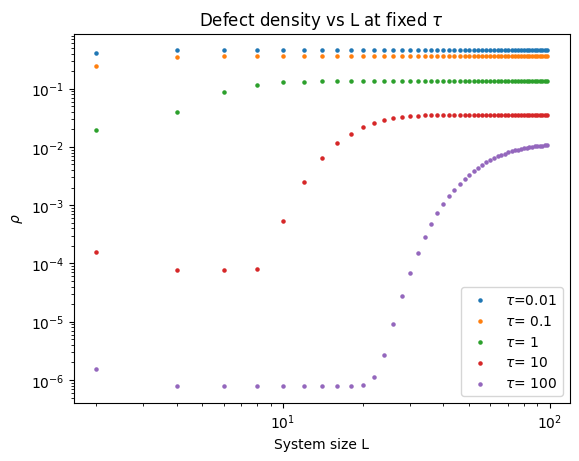

In [122]:
def rho_vs_L(tau0,Ls):
    """return rho(L) for fixed tau0"""
    rho = []
    for L in tqdm(Ls):
        state = kz.state(L, tau0, tau0)
        val = (1 - kz.G(1, state)) / 2   # defect density
        rho.append(val)
    return np.array(rho)

Ls = np.arange(2,100,2)
# example: pick tau0 = 1.0
tau0 = .01
tau1= .1
tau2 = 1
tau3 = 10
tau4 = 100
rho_tau0 = rho_vs_L(tau0,Ls)
rho_tau1 = rho_vs_L(tau1,Ls)
rho_tau2 = rho_vs_L(tau2,Ls)
rho_tau3 = rho_vs_L(tau3,Ls)
rho_tau4 = rho_vs_L(tau4,Ls)
# now you can plot
fig, ax = plt.subplots()
ax.scatter(Ls, rho_tau0, s=5,label=fr"$\tau$={tau0}")
ax.scatter(Ls, rho_tau1,s=5,label=rf"$\tau$= {tau1}")
ax.scatter(Ls, rho_tau2,s=5,label=rf"$\tau$= {tau2}")
ax.scatter(Ls, rho_tau3,s=5,label=rf"$\tau$= {tau3}")
ax.scatter(Ls, rho_tau4,s=5,label=rf"$\tau$= {tau4}")

ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("System size L")
ax.set_ylabel(r"$\rho$")
ax.set_title(r"Defect density vs L at fixed $\tau$")
plt.show()


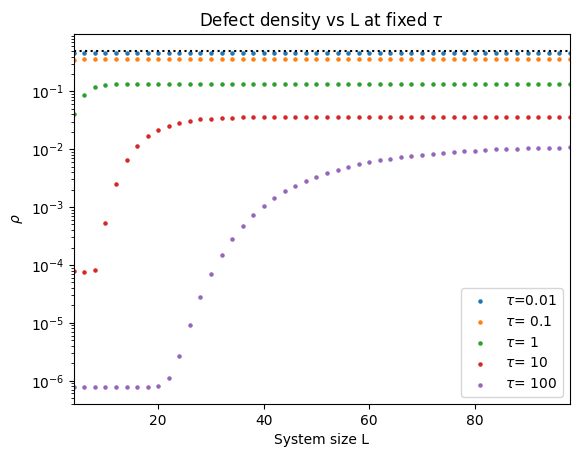

In [125]:
fig, ax = plt.subplots()
ax.scatter(Ls, rho_tau0, s=5,label=fr"$\tau$={tau0}")
ax.scatter(Ls, rho_tau1,s=5,label=rf"$\tau$= {tau1}")
ax.scatter(Ls, rho_tau2,s=5,label=rf"$\tau$= {tau2}")
ax.scatter(Ls, rho_tau3,s=5,label=rf"$\tau$= {tau3}")
ax.scatter(Ls, rho_tau4,s=5,label=rf"$\tau$= {tau4}")
ax.hlines(0.5,Ls[0],Ls[-1],ls=":",color="black")
ax.legend()
#ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(4,Ls[-1])
#ax.set_ylim(10e-4,0.5)

ax.set_xlabel("System size L")
ax.set_ylabel(r"$\rho$")
ax.set_title(r"Defect density vs L at fixed $\tau$")
plt.show()

#fig.savefig("Fixed_tau_vs_system_sizeLINEAR.pdf")

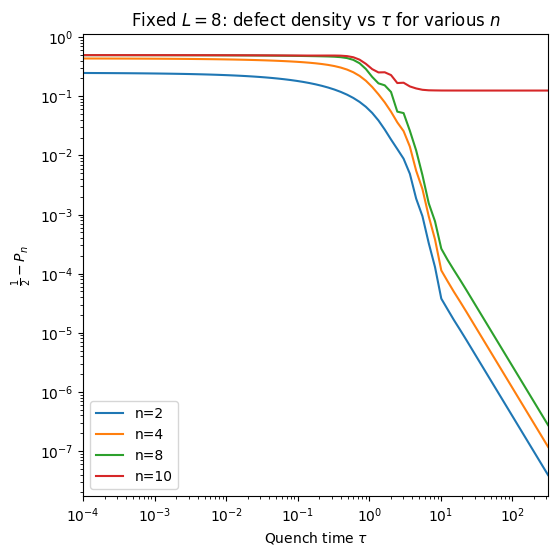

In [176]:
# choose which L to inspect
L_index = 2    # e.g. Ls[3] = 16
Lval = Ls[L_index]

# choose list of n values
n_list = [2, 4, 8, 10]

fig, ax = plt.subplots(figsize=(6,6))

for n in n_list:
    data = []
    for s in states_L[L_index]:        # states at this L
        data.append(0.5 - kz.P_n(n, s))
    data = np.array(data)
    ax.plot(taus, data, label=f"n={n}")

ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(taus[0], taus[-1])

ax.set_xlabel(r"Quench time $\tau$")
ax.set_ylabel(r"$\frac{1}{2} - P_n$")
ax.set_title(fr"Fixed $L={Lval}$: defect density vs $\tau$ for various $n$")

plt.show()


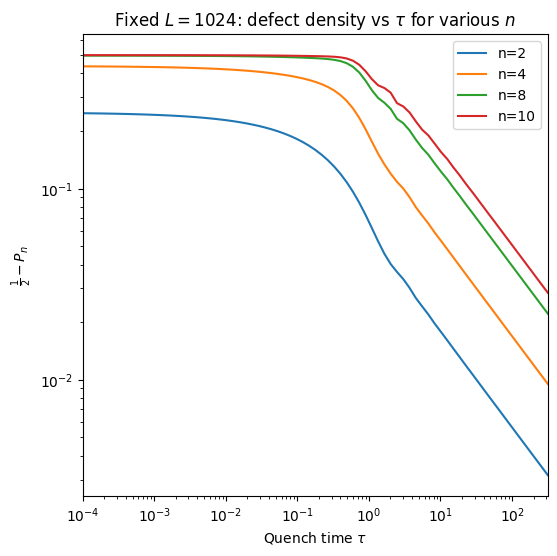

In [175]:
# choose which L to inspect
L_index = -1       # e.g. Ls[3] = 16
Lval = Ls[L_index]

# choose list of n values
n_list = [2, 4, 8, 10]

fig, ax = plt.subplots(figsize=(6,6))

for n in n_list:
    data = []
    for s in states_L[L_index]:        # states at this L
        data.append(0.5 - kz.P_n(n, s))
    data = np.array(data)
    ax.plot(taus, data, label=f"n={n}")

ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(taus[0], taus[-1])

ax.set_xlabel(r"Quench time $\tau$")
ax.set_ylabel(r"$\frac{1}{2} - P_n$")
ax.set_title(fr"Fixed $L={Lval}$: defect density vs $\tau$ for various $n$")

plt.show()


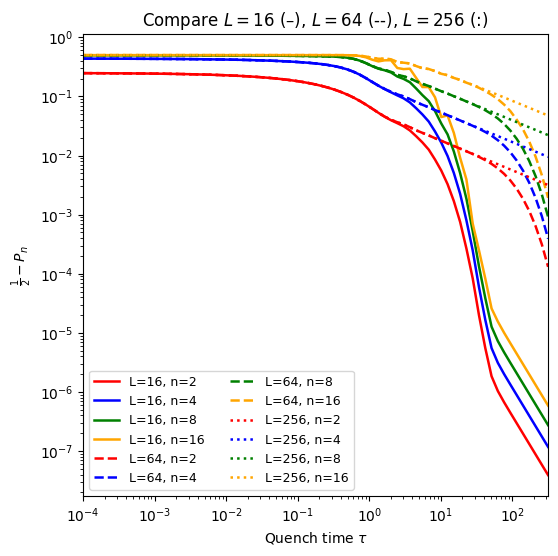

In [193]:
# choose three system sizes
L_index_line    = 3   # solid
L_index_dash    = 5   # dashed
L_index_dot     = 7  # dotted
Lval_line, Lval_dash, Lval_dot = Ls[L_index_line], Ls[L_index_dash], Ls[L_index_dot]

n_list  = [2, 4, 8, 16]
colors  = ["red", "blue", "green", "orange"]
cmap    = dict(zip(n_list, colors))

fig, ax = plt.subplots(figsize=(6,6))

# First L: solid
for n in n_list:
    data = [0.5 - kz.P_n(n, s) for s in states_L[L_index_line]]
    ax.plot(taus, data, color=cmap[n], lw=1.8, ls="-", label=f"L={Lval_line}, n={n}")

# Second L: dashed
for n in n_list:
    data = [0.5 - kz.P_n(n, s) for s in states_L[L_index_dash]]
    ax.plot(taus, data, color=cmap[n], lw=1.8, ls="--", label=f"L={Lval_dash}, n={n}")

# Third L: dotted
for n in n_list:
    data = [0.5 - kz.P_n(n, s) for s in states_L[L_index_dot]]
    ax.plot(taus, data, color=cmap[n], lw=1.8, ls=":", label=f"L={Lval_dot}, n={n}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(taus[0], taus[-1])

ax.set_xlabel(r"Quench time $\tau$")
ax.set_ylabel(r"$\frac{1}{2} - P_n$")
ax.set_title(fr"Compare $L={Lval_line}$ (–), $L={Lval_dash}$ (--), $L={Lval_dot}$ (:)")
ax.legend(ncol=2, fontsize=9)
plt.show()


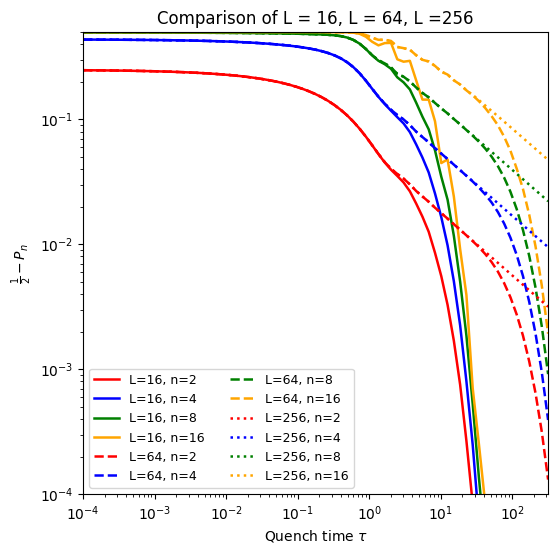

In [195]:
ax.set_ylim(10e-5,0.5)
ax.set_title("Comparison of L = 16, L = 64, L =256")
fig

In [203]:
sigma_general([0,2],s)

1
0
2
1


np.float64(0.0)

In [133]:
#ax.set_xlim(1,50)
ax.set_ylabel(r"Expectation Value $\langle P_{16} \rangle$")
ax.set_xlabel(r"Quench time $\tau$")
ax.set_title(r"$G_1$ approximation for $P_{16}$")
fig.savefig("P16.png")

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_11459/2290264212.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


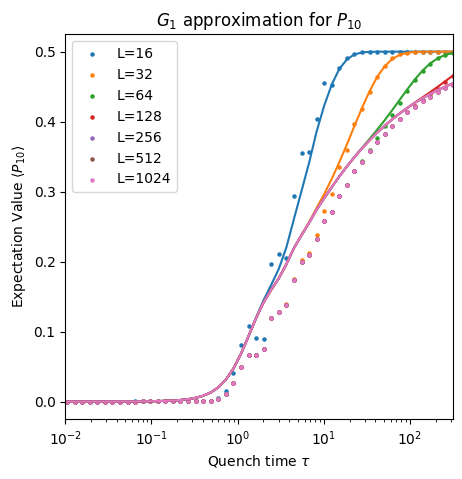

<Figure size 640x480 with 0 Axes>

In [129]:
##Plot:
n= 16
fig, ax = plt.subplots(figsize=(5,5))
a=0 #y axis
b=0 #x axis
plt.figure()
for i,states in enumerate(states_L[:]):
    if Ls[i]<n:
        continue
    data = []
    p_data = []
    for s in states:
        p = (1-kz.G(1,s))/2
        P4= kz.P_n(n,s)
        data.append(P4)
        p_data.append(p)
    data=np.array(data)
    p_data=np.array(p_data)
    ax.scatter(taus,data,label=f"L={Ls[i]}",s=5)
    ax.plot(taus,1/2*(1-p_data)**(n-1))
   # ax.plot(taus,1/data,label="1/DATA")
#ax.plot(taus,(taus**(-1/2)/taus[31]**(-1/2))/2,ls="--",color="black",lw=1,label=r"$\tau^{-1/2}$")
# plot(taus,taus**(-4/2),ls="--",color="black")

ax.legend()

ax.set_xscale("log")
ax.set_xlim(.01,taus[-1])
#ax.set_yscale("log")

#ax.set_ylim(1,16)
#ax.set_xlim(1,50)
ax.set_ylabel(r"Expectation Value $\langle P_{10} \rangle$")
ax.set_xlabel(r"Quench time $\tau$")
ax.set_title(r"$G_1$ approximation for $P_{10}$")
fig.show()
#fig.savefig("Defect_density_finite_size.png")

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_11459/1398301071.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


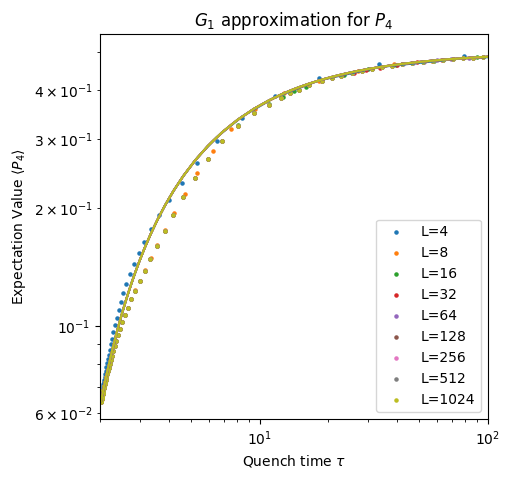

<Figure size 640x480 with 0 Axes>

In [126]:
##Plot:
fig, ax = plt.subplots(figsize=(5,5))
a=0 #y axis
b=0 #x axis
plt.figure()
for i,states in enumerate(states_L[:]):
    if i==0:
        continue
    data = []
    p_data = []
    for s in states:
        p = (1-kz.G(1,s))/2
        P4= kz.P_n(4,s)
        data.append(P4)
        p_data.append(p)
    data=np.array(data)
    p_data=np.array(p_data)
    ax.scatter(1/p_data,data,label=f"L={Ls[i]}",s=5)
    ax.plot(1/p_data,1/2*(1-p_data)**3)
   # ax.plot(taus,1/data,label="1/DATA")
#ax.plot(taus,(taus**(-1/2)/taus[31]**(-1/2))/2,ls="--",color="black",lw=1,label=r"$\tau^{-1/2}$")
# plot(taus,taus**(-4/2),ls="--",color="black")

ax.legend()

ax.set_xscale("log")
#ax.set_xlim(.001,taus[-1])
ax.set_yscale("log")

#ax.set_ylim(1,16)
ax.set_xlim(2,100)
ax.set_ylabel(r"Expectation Value $\langle P_4 \rangle$")
ax.set_xlabel(r"Quench time $\tau$")
ax.set_title(r"$G_1$ approximation for $P_4$")
fig.show()
#fig.savefig("Defect_density_finite_size.png")